# Decision Trees & Random Forests — TensorFlow (CPU)

CPU tensor ops implementation of Decision Trees and Random Forests using TensorFlow on Windows (TF 2.11+ dropped native GPU support). Same **vectorized split search** as PyTorch — `tf.sort` + `tf.cumsum` evaluates all candidate thresholds simultaneously — but running entirely on CPU.

## Pipeline Structure
- **Part 1: Decision Tree** — TF-accelerated split search, depth analysis sweep, unrestricted tree baseline
- **Part 2: Random Forest** — Bootstrap aggregation with TF split search, 100 trees with random feature subsets
- **Showcase: TF CPU vs NumPy Split Search** — Same sorted-scan algorithm implemented with TF tensor ops vs raw NumPy

## Key TensorFlow Operations
| Operation | TensorFlow Function | Replaces |
|-----------|-------------------|----------|
| Sort features for threshold scan | `tf.sort()` + `tf.argsort()` | `np.argsort()` |
| Running class counts (left/right) | `tf.cumsum()` | Python for-loop accumulator |
| Vectorized Gini at all thresholds | TF tensor arithmetic | Per-threshold Python calculation |
| Best threshold selection | `tf.argmax()` | Python `max()` tracking |
| Bootstrap sampling | `tf.random.uniform()` | `np.random.choice()` |
| Data partitioning | `tf.boolean_mask()` | NumPy boolean indexing |
| Reorder by sorted indices | `tf.gather()` | Direct array indexing |

## Dataset
Bank Marketing (UCI) — 41,188 samples, 19 features, binary classification (88.7/11.3 class imbalance).

## Note on GPU
TF 2.11+ removed native Windows GPU support. This pipeline runs on CPU. GPU acceleration via WSL2 is planned for neural network models (DNNs/CNNs).

In [1]:
# Step 1: Imports and configuration
import sys
import os
import time
import pickle
import numpy as np
import tensorflow as tf

# Add project root to path for shared utilities
sys.path.insert(0, os.path.abspath('../..'))
from utils.data_loader import load_processed_data
from utils.performance import track_performance, track_inference
from utils.metrics import evaluate_classifier, print_metrics, accuracy
from utils.visualization import (plot_confusion_matrix, plot_roc_curve,
                                  plot_feature_importance, plot_calibration_curve,
                                  plot_tree_depth_analysis, plot_forest_convergence)
from utils.results import build_results_dict, save_results, add_result, print_comparison
from utils.tree_utils import compute_feature_importance, flatten_tree

# Configuration
# ============================================================
RANDOM_STATE = 113
FRAMEWORK = 'TensorFlow'
DEPTH_VALUES = [2, 3, 5, 7, 10, 15, 20, None]
N_ESTIMATORS = 100
MAX_FEATURES = 'sqrt'    # sqrt(19) ≈ 4 features per split
RESULTS_DIR = 'results'

# Reproducibility
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Device info (TF 2.11+ dropped native Windows GPU support)
# ============================================================
gpus = tf.config.list_physical_devices('GPU')
print(f"TensorFlow {tf.__version__}")
print(f"GPUs available: {len(gpus)} {'(CPU only)' if not gpus else gpus}")

# Load data and convert to TF tensors
# ============================================================
X_train, X_test, y_train, y_test, meta = load_processed_data('decision_tree')

# Features as float32 (sufficient for split thresholds), labels as int64
X_train_t = tf.constant(X_train, dtype=tf.float32)
X_test_t = tf.constant(X_test, dtype=tf.float32)
y_train_t = tf.constant(y_train, dtype=tf.int64)
y_test_t = tf.constant(y_test, dtype=tf.int64)

feature_names = meta['feature_names']
n_features = X_train.shape[1]
n_classes = len(meta['class_names'])

os.makedirs(RESULTS_DIR, exist_ok=True)

# Dataset overview
# ============================================================
print(f"\n{'=' * 60}")
print(f"DATASET: {meta['dataset']}")
print(f"{'=' * 60}")
print(f"  Train: {X_train_t.shape[0]:,} samples, {n_features} features")
print(f"  Test:  {X_test_t.shape[0]:,} samples")
print(f"  Classes: {n_classes} — {meta['class_names']}")

# Class distribution
train_counts = tf.reduce_sum(tf.one_hot(y_train_t, n_classes, dtype=tf.float32), axis=0)
print(f"  Train distribution: {int(train_counts[0].numpy()):,} no ({train_counts[0].numpy()/len(y_train_t)*100:.1f}%) | "
      f"{int(train_counts[1].numpy()):,} yes ({train_counts[1].numpy()/len(y_train_t)*100:.1f}%)")
print(f"  Tensor dtype: {X_train_t.dtype} (features), {y_train_t.dtype} (labels)")

TensorFlow 2.20.0
GPUs available: 0 (CPU only)

DATASET: Bank Marketing (UCI)
  Train: 32,950 samples, 19 features
  Test:  8,238 samples
  Classes: 2 — ['no', 'yes']
  Train distribution: 29,238 no (88.7%) | 3,712 yes (11.3%)
  Tensor dtype: <dtype: 'float32'> (features), <dtype: 'int64'> (labels)


In [2]:
# Step 2: TF-accelerated split criterion functions

"""
Balanced class weights + Gini impurity + vectorized split search
Same algorithm as PyTorch but using TF ops:
  torch.sort → tf.sort + tf.argsort (separate calls in TF)
  torch.cumsum → tf.cumsum
  tensor[mask] → tf.boolean_mask
  tensor[indices] → tf.gather
"""

def compute_sample_weights(y_t):
    """
    Compute balanced class weights as per-sample weight tensor.
    
    Formula: weight_k = n_samples / (n_classes * n_samples_k)
    Same as sklearn's class_weight='balanced'.
    
    Args:
        y_t: Label tensor (int64) — tf.constant
        
    Returns:
        Tensor of per-sample weights (float32)
    """
    classes, _, counts = tf.unique_with_counts(y_t)
    n_samples = tf.shape(y_t)[0]
    n_cls = tf.shape(classes)[0]
    
    # Weight per class: n / (n_classes * n_k)
    class_weights = tf.cast(n_samples, tf.float32) / (
        tf.cast(n_cls, tf.float32) * tf.cast(counts, tf.float32))
    
    # tf.unique returns classes in order of first appearance, not sorted.
    # Since y_t uses 0/1 labels and 0 appears first in training data,
    # classes will be [0, 1] — matching index order. Use tf.gather to map.
    # Build a lookup: class_weights_lookup[class_label] = weight
    max_class = tf.reduce_max(y_t) + 1
    class_weights_lookup = tf.scatter_nd(
        tf.cast(tf.expand_dims(classes, 1), tf.int32),
        class_weights,
        shape=[tf.cast(max_class, tf.int32)])
    
    # Map to per-sample weights
    sample_weights = tf.gather(class_weights_lookup, tf.cast(y_t, tf.int32))
    return sample_weights

def gini_impurity_tf(y_t, sample_weight_t):
    """
    Weighted Gini impurity: 1 - sum(p_k^2).
    
    Args:
        y_t: Label tensor (int64)
        sample_weight_t: Per-sample weight tensor (float32)
        
    Returns:
        Python float — Gini impurity value
    """
    if tf.shape(y_t)[0] == 0:
        return 0.0
    
    classes = tf.unique(y_t)[0]
    total_weight = tf.reduce_sum(sample_weight_t)
    
    if total_weight == 0:
        return 0.0
    
    sum_sq = 0.0
    for c in classes:
        mask = tf.equal(y_t, c)
        p_k = tf.reduce_sum(tf.boolean_mask(sample_weight_t, mask)) / total_weight
        sum_sq += p_k.numpy() ** 2
    
    return 1.0 - sum_sq


def find_best_split_tf(X_t, y_t, sample_weight_t, feature_indices=None):
    """
    TF-accelerated best split search using tf.sort + tf.cumsum.
    
    For each candidate feature:
      1. Sort feature values (tf.sort + tf.argsort — two separate calls in TF)
      2. Reorder labels and weights by sorted order (tf.gather)
      3. Compute running left-side weighted class counts (tf.cumsum)
      4. Derive right-side counts = total - left
      5. Compute Gini impurity at ALL thresholds simultaneously
      6. Select threshold with maximum information gain (tf.argmax)
    
    Same vectorized algorithm as PyTorch, different API surface.
    
    Args:
        X_t: Feature tensor (n_samples, n_features) float32
        y_t: Label tensor (n_samples,) int64
        sample_weight_t: Per-sample weights (n_samples,) float32
        feature_indices: Optional list of feature indices to consider
                        (used by RF for random feature subsets)
    
    Returns:
        Dict {'feature': int, 'threshold': float, 'gain': float} or None
    """
    n_samples = X_t.shape[0]
    n_features_total = X_t.shape[1]
    
    if feature_indices is None:
        feature_indices = range(n_features_total)
    
    # Parent impurity (computed once)
    total_weight = tf.reduce_sum(sample_weight_t)
    parent_gini = gini_impurity_tf(y_t, sample_weight_t)
    
    best_gain = 0.0
    best_feature = None
    best_threshold = None
    
    # Precompute total weighted counts per class
    n_cls = int(tf.reduce_max(y_t).numpy()) + 1
    total_class_weights = tf.zeros(n_cls, dtype=tf.float32)
    for c in range(n_cls):
        mask = tf.equal(y_t, tf.constant(c, dtype=y_t.dtype))
        total_class_weights = total_class_weights + tf.one_hot(c, n_cls) * tf.reduce_sum(
            tf.boolean_mask(sample_weight_t, mask))
    
    for f in feature_indices:
        # 1. Sort feature values — TF splits into two calls (unlike PyTorch's single torch.sort)
        col = X_t[:, f]
        sorted_values = tf.sort(col)
        sorted_indices = tf.argsort(col)
        
        # Cast to int64 for tf.gather compatibility with int64 labels
        sorted_indices = tf.cast(sorted_indices, tf.int64)
        
        # 2. Reorder labels and weights by sorted order
        sorted_y = tf.gather(y_t, sorted_indices)
        sorted_w = tf.gather(sample_weight_t, tf.cast(sorted_indices, tf.int32))
        
        # 3. Build per-class weight columns for cumsum
        # One-hot encode sorted labels, multiply by weights
        class_indicators = tf.one_hot(tf.cast(sorted_y, tf.int32), n_cls, dtype=tf.float32)
        class_indicators = class_indicators * tf.expand_dims(sorted_w, 1)
        
        # 4. Cumulative sum gives running left-side class weights at each position
        left_class_weights = tf.cumsum(class_indicators, axis=0)  # (n_samples, n_cls)
        
        # 5. Right-side class weights = total - left
        right_class_weights = tf.expand_dims(total_class_weights, 0) - left_class_weights
        
        # 6. Compute Gini for all split positions simultaneously
        # Only consider splits where consecutive values differ
        valid_splits = tf.not_equal(sorted_values[:-1], sorted_values[1:])
        valid_splits = tf.cast(valid_splits, tf.float32)
        
        if tf.reduce_sum(valid_splits) == 0:
            continue  # All values identical for this feature
        
        # Left side: positions 0..i (inclusive) → use [:-1]
        left_w = left_class_weights[:-1]       # (n-1, n_cls)
        right_w = right_class_weights[:-1]     # (n-1, n_cls)
        
        left_total = tf.reduce_sum(left_w, axis=1)    # (n-1,)
        right_total = tf.reduce_sum(right_w, axis=1)  # (n-1,)
        
        # Avoid division by zero
        left_total_safe = tf.maximum(left_total, 1e-10)
        right_total_safe = tf.maximum(right_total, 1e-10)
        
        # Gini = 1 - sum(p_k^2) where p_k = class_weight_k / total_weight
        left_p = left_w / tf.expand_dims(left_total_safe, 1)
        right_p = right_w / tf.expand_dims(right_total_safe, 1)
        
        left_gini = 1.0 - tf.reduce_sum(left_p ** 2, axis=1)    # (n-1,)
        right_gini = 1.0 - tf.reduce_sum(right_p ** 2, axis=1)  # (n-1,)
        
        # Weighted average impurity of children
        total_w = total_weight
        weighted_child_gini = (left_total / total_w) * left_gini + \
                              (right_total / total_w) * right_gini
        
        # Information gain = parent_gini - weighted_child_gini
        gains = parent_gini - weighted_child_gini  # (n-1,)
        
        # Mask out invalid splits (consecutive identical values)
        gains = gains * valid_splits
        
        # Find best threshold for this feature
        best_idx = int(tf.argmax(gains).numpy())
        feature_gain = float(gains[best_idx].numpy())
        
        if feature_gain > best_gain:
            best_gain = feature_gain
            best_feature = int(f) if not isinstance(f, int) else f
            # Threshold = midpoint between sorted_values[best_idx] and sorted_values[best_idx + 1]
            best_threshold = (float(sorted_values[best_idx].numpy()) +
                              float(sorted_values[best_idx + 1].numpy())) / 2.0
    
    if best_feature is None:
        return None
    
    return {'feature': best_feature, 'threshold': best_threshold, 'gain': best_gain}

In [3]:
# Quick test
sample_weight_t = compute_sample_weights(y_train_t)

print(f"{'=' * 60}")
print(f"SPLIT CRITERION FUNCTIONS — TF CPU")
print(f"{'=' * 60}")
print(f"  Class 0 weight: {sample_weight_t[y_train_t == 0][0].numpy():.4f}")
print(f"  Class 1 weight: {sample_weight_t[y_train_t == 1][0].numpy():.4f}")
print(f"  Weighted Gini (full train): {gini_impurity_tf(y_train_t, sample_weight_t):.4f}")

# Test split search on full training data
t0 = time.perf_counter()
best = find_best_split_tf(X_train_t, y_train_t, sample_weight_t)
split_time = time.perf_counter() - t0

print(f"\n  Best split: {feature_names[best['feature']]} <= {best['threshold']:.4f}")
print(f"  Information gain: {best['gain']:.6f}")
print(f"  Split search time: {split_time:.4f}s (TF CPU, all 19 features)")

SPLIT CRITERION FUNCTIONS — TF CPU
  Class 0 weight: 0.5635
  Class 1 weight: 4.4383
  Weighted Gini (full train): 0.5000

  Best split: nr.employed <= 5087.6501
  Information gain: 0.098501
  Split search time: 0.1700s (TF CPU, all 19 features)


In [4]:
# Step 4: Tree building (recursive) + prediction helpers

"""
Tree structure: Python dicts on CPU (recursive by nature)
Split search: TF tensor ops via find_best_split_tf()
Same dict format as PyTorch/No-Framework for tree_utils.py compatibility
"""

def build_tree_tf(X_t, y_t, sample_weight_t, n_classes, max_depth=None, min_samples_split=2, depth=0):
    """
    Recursively build a decision tree using TF-accelerated split search.

    Returns nested dict — split nodes have 'feature' key, leaves don't.
    n_classes is passed explicitly (never computed from local y_t.max())
    to ensure all leaf 'value' arrays have consistent length.

    Args:
        X_t: tf.Tensor (n_samples, n_features) float32
        y_t: tf.Tensor (n_samples,) int64
        sample_weight_t: tf.Tensor (n_samples,) float32
        n_classes: int — total number of classes (2 for binary)
        max_depth: int or None — max tree depth (None = no limit)
        min_samples_split: int — minimum samples to attempt a split
        depth: int — current depth (internal, starts at 0)

    Returns:
        dict: tree node with keys depending on type:
            Split: feature, threshold, left, right, n_samples, impurity, value
            Leaf: value, n_samples, impurity
    """
    n_samples = X_t.shape[0]

    # Class distribution — weighted counts per class
    # tf.one_hot + multiply by weights, then sum
    one_hot = tf.one_hot(tf.cast(y_t, tf.int32), depth=n_classes, dtype=tf.float32)
    weighted_counts = tf.reduce_sum(one_hot * sample_weight_t[:, tf.newaxis], axis=0)
    value = weighted_counts.numpy().tolist()  # Python list for dict storage

    impurity = float(gini_impurity_tf(y_t, sample_weight_t))

    # Stopping conditions
    # 1. Pure node (all same class)
    unique_classes = tf.unique(y_t)[0]
    if tf.shape(unique_classes)[0] == 1:
        return {'value': value, 'n_samples': int(n_samples), 'impurity': 0.0}

    # 2. Max depth reached
    if max_depth is not None and depth >= max_depth:
        return {'value': value, 'n_samples': int(n_samples), 'impurity': impurity}

    # 3. Too few samples to split
    if n_samples < min_samples_split:
        return {'value': value, 'n_samples': int(n_samples), 'impurity': impurity}

    # Find best split using TF ops
    best = find_best_split_tf(X_t, y_t, sample_weight_t)

    # 4. No valid split found (all features constant)
    if best is None:
        return {'value': value, 'n_samples': int(n_samples), 'impurity': impurity}

    best_feature = best['feature']
    best_threshold = best['threshold']
    best_gain = best['gain']

    # 5. No information gain
    if best_gain <= 0:
        return {'value': value, 'n_samples': int(n_samples), 'impurity': impurity}

    # Partition data using boolean mask
    feature_values = X_t[:, best_feature]
    left_mask = feature_values <= best_threshold
    right_mask = ~left_mask

    X_left = tf.boolean_mask(X_t, left_mask)
    y_left = tf.boolean_mask(y_t, left_mask)
    w_left = tf.boolean_mask(sample_weight_t, left_mask)

    X_right = tf.boolean_mask(X_t, right_mask)
    y_right = tf.boolean_mask(y_t, right_mask)
    w_right = tf.boolean_mask(sample_weight_t, right_mask)

    # 6. One side is empty (shouldn't happen with valid gain, but safety check)
    if X_left.shape[0] == 0 or X_right.shape[0] == 0:
        return {'value': value, 'n_samples': int(n_samples), 'impurity': impurity}

    # Recurse
    left_child = build_tree_tf(X_left, y_left, w_left, n_classes,
                               max_depth=max_depth, min_samples_split=min_samples_split,
                               depth=depth + 1)
    right_child = build_tree_tf(X_right, y_right, w_right, n_classes,
                                max_depth=max_depth, min_samples_split=min_samples_split,
                                depth=depth + 1)

    return {
        'feature': int(best_feature),
        'threshold': float(best_threshold),
        'left': left_child,
        'right': right_child,
        'n_samples': int(n_samples),
        'impurity': impurity,
        'value': value
    }


def flat_tree_to_tf(flat_tree):
    """
    Convert flatten_tree() numpy output to TF tensors with correct dtypes.

    flatten_tree returns int32 for indices/children and float64 for thresholds/values.
    TF's tf.gather needs int64 indices, so we cast accordingly.

    Args:
        flat_tree: dict from tree_utils.flatten_tree() with numpy arrays

    Returns:
        dict with same keys but TF tensor values:
            int arrays → tf.int64, float arrays → tf.float32
    """
    return {
        'feature_indices': tf.constant(flat_tree['feature_indices'], dtype=tf.int64),
        'thresholds': tf.constant(flat_tree['thresholds'], dtype=tf.float32),
        'left_children': tf.constant(flat_tree['left_children'], dtype=tf.int64),
        'right_children': tf.constant(flat_tree['right_children'], dtype=tf.int64),
        'values': tf.constant(flat_tree['values'], dtype=tf.float32)
    }


def predict_tree_tf(flat_tf, X_t):
    """
    Batch prediction using flat TF tensors (no Python recursion).

    All samples start at root (node 0). Each iteration routes samples at
    internal nodes left or right based on feature value vs threshold.
    Uses tf.gather for node lookups, tf.where for conditional routing.

    Args:
        flat_tf: dict from flat_tree_to_tf() with TF tensors
        X_t: tf.Tensor (n_samples, n_features) float32

    Returns:
        predictions: tf.Tensor (n_samples,) int64 — predicted class labels
        probabilities: tf.Tensor (n_samples, n_classes) float32 — class probabilities
    """
    n_samples = X_t.shape[0]
    feature_indices = flat_tf['feature_indices']
    thresholds = flat_tf['thresholds']
    left_children = flat_tf['left_children']
    right_children = flat_tf['right_children']
    values = flat_tf['values']

    # All samples start at root
    node_ids = tf.zeros(n_samples, dtype=tf.int64)

    # Route until all samples reach leaves (feature_index == -1)
    while True:
        # Which samples are at internal (non-leaf) nodes?
        current_features = tf.gather(feature_indices, node_ids)
        at_internal = tf.not_equal(current_features, -1)

        if not tf.reduce_any(at_internal):
            break

        # Get threshold for each sample's current node
        current_thresholds = tf.gather(thresholds, node_ids)

        # Get each sample's value for its current node's split feature
        # tf.gather_nd to index X_t[sample_i, feature_i]
        # Clamp -1 (leaf) to 0 — gathered values won't be used (at_internal protects)
        safe_features = tf.where(at_internal, current_features, tf.zeros_like(current_features))
        sample_indices = tf.range(n_samples, dtype=tf.int64)
        gather_indices = tf.stack([sample_indices, safe_features], axis=1)

        sample_values = tf.gather_nd(X_t, tf.cast(gather_indices, tf.int32))

        # Route: left if value <= threshold, right otherwise
        go_left = sample_values <= current_thresholds

        # New node IDs: left or right child
        left_ids = tf.gather(left_children, node_ids)
        right_ids = tf.gather(right_children, node_ids)
        new_node_ids = tf.where(go_left, left_ids, right_ids)

        # Only update samples that were at internal nodes
        node_ids = tf.where(at_internal, new_node_ids, node_ids)

    # All at leaves — extract class distributions
    leaf_values = tf.gather(values, node_ids)  # (n_samples, n_classes)

    # Normalize to probabilities
    row_sums = tf.reduce_sum(leaf_values, axis=1, keepdims=True)
    probabilities = tf.where(row_sums > 0, leaf_values / row_sums, 0.0)

    # Clamp for float32 safety (log-loss needs no zeros)
    probabilities = tf.clip_by_value(probabilities, 1e-7, 1.0 - 1e-7)

    # Predicted class = argmax
    predictions = tf.argmax(leaf_values, axis=1)

    return predictions, probabilities


def get_tree_depth(node):
    """Get maximum depth of a recursive dict tree."""
    if 'feature' not in node:
        return 0
    return 1 + max(get_tree_depth(node['left']), get_tree_depth(node['right']))


def get_n_leaves(node):
    """Count leaf nodes in a recursive dict tree."""
    if 'feature' not in node:
        return 1
    return get_n_leaves(node['left']) + get_n_leaves(node['right'])

In [5]:
# Quick test: depth-3 tree
print("=" * 60)
print("QUICK TEST — Depth-3 Tree")
print("=" * 60)

test_tree = build_tree_tf(X_train_t, y_train_t, sample_weight_t, n_classes,
                          max_depth=3)
test_depth = get_tree_depth(test_tree)
test_leaves = get_n_leaves(test_tree)
print(f"  Tree depth: {test_depth}, Leaves: {test_leaves}")
print(f"  Root split: feature {test_tree['feature']} "
      f"({feature_names[test_tree['feature']]}) <= {test_tree['threshold']:.4f}")

# Flatten → TF tensors → predict
from utils.tree_utils import flatten_tree
flat_test = flatten_tree(test_tree)
flat_test_tf = flat_tree_to_tf(flat_test)
preds, probs = predict_tree_tf(flat_test_tf, X_test_t)

test_acc = np.mean(preds.numpy() == y_test)
print(f"  Test accuracy (depth 3): {test_acc:.4f}")
print(f"  Prediction shape: {preds.shape}, Proba shape: {probs.shape}")
print(f"  Sample probabilities (first 3): {probs[:3].numpy()}")

QUICK TEST — Depth-3 Tree
  Tree depth: 3, Leaves: 8
  Root split: feature 18 (nr.employed) <= 5087.6501
  Test accuracy (depth 3): 0.8345
  Prediction shape: (8238,), Proba shape: (8238, 2)
  Sample probabilities (first 3): [[0.63715076 0.3628492 ]
 [0.63715076 0.3628492 ]
 [0.63715076 0.3628492 ]]


In [6]:
# Step 5: Unrestricted Decision Tree — training + evaluation

"""
No depth limit — tree grows until all leaves are pure or unsplittable.
Demonstrates overfitting: near-perfect train, poor test generalization.
"""

print("=" * 60)
print("PART 1: DECISION TREE (Unrestricted Depth)")
print("=" * 60)

# Train unrestricted tree
with track_performance() as dt_perf:
    tree = build_tree_tf(X_train_t, y_train_t, sample_weight_t, n_classes)

depth = get_tree_depth(tree)
n_leaves = get_n_leaves(tree)
print(f"\n  [1/3] Tree built in {dt_perf['time']:.1f}s")
print(f"  Depth: {depth}, Leaves: {n_leaves:,}")
print(f"  Root split: {feature_names[tree['feature']]} <= {tree['threshold']:.4f}")
print(f"  Peak memory: {dt_perf['memory']:.2f} MB")

# Flatten → TF tensors → predict
flat_tree_np = flatten_tree(tree)
flat_tree_tf_tensors = flat_tree_to_tf(flat_tree_np)

# Train predictions
train_preds, train_probs = predict_tree_tf(flat_tree_tf_tensors, X_train_t)
dt_train_metrics = evaluate_classifier(y_train, train_preds.numpy(), train_probs[:, 1].numpy())

# Test predictions
test_preds, test_probs = predict_tree_tf(flat_tree_tf_tensors, X_test_t)
dt_test_metrics = evaluate_classifier(y_test, test_preds.numpy(), test_probs[:, 1].numpy())

print(f"\n  [2/3] Predictions complete")
print_metrics(dt_train_metrics, dt_test_metrics, title="Decision Tree (Unrestricted)")

# Store for depth analysis (reuse unrestricted tree for depth=None)
dt_train_probs = train_probs
dt_test_probs = test_probs
dt_test_preds = test_preds

print(f"\n  [3/3] Decision tree complete")

PART 1: DECISION TREE (Unrestricted Depth)

  [1/3] Tree built in 462.0s
  Depth: 42, Leaves: 5,381
  Root split: nr.employed <= 5087.6501
  Peak memory: 4.01 MB

  [2/3] Predictions complete

METRICS — Decision Tree (Unrestricted)
Metric                           Train         Test
-------------------------------------------------
accuracy                        0.9940       0.8435
precision                       0.9491       0.3149
recall                          1.0000       0.3308
f1                              0.9739       0.3226
auc                             0.9999       0.6206
log_loss                        0.0128       2.4120
brier_score                     0.0045       0.1548
ece                             0.8858       0.8863

  [3/3] Decision tree complete


DEPTH ANALYSIS
  [1/8] Depth=2 ... Train: 0.8353, Test: 0.8344
  [2/8] Depth=3 ... Train: 0.8354, Test: 0.8345
  [3/8] Depth=5 ... Train: 0.8154, Test: 0.8106
  [4/8] Depth=7 ... Train: 0.8217, Test: 0.8126
  [5/8] Depth=10 ... Train: 0.8399, Test: 0.8173
  [6/8] Depth=15 ... Train: 0.8794, Test: 0.8193
  [7/8] Depth=20 ... Train: 0.9221, Test: 0.8197
  [8/8] Depth=None ... Train: 0.9940, Test: 0.8435


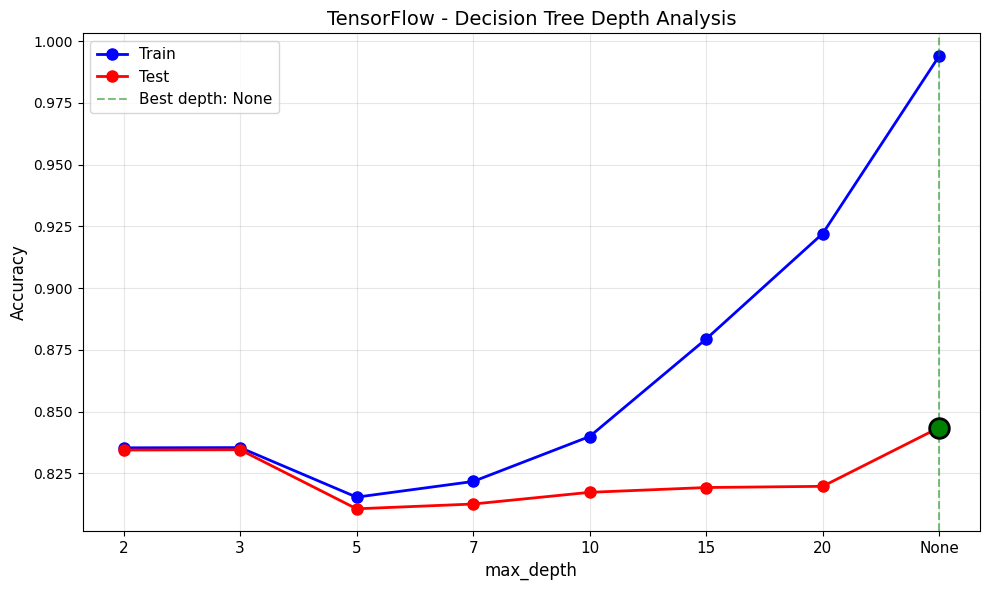


  Saved: results/dt_depth_analysis.png


In [7]:
# Step 6: Depth analysis — accuracy vs tree depth
"""
Sweep depth values to find optimal complexity tradeoff.
Reuses the unrestricted tree (depth=None) already built.
"""

print("=" * 60)
print("DEPTH ANALYSIS")
print("=" * 60)

train_scores = []
test_scores = []

for i, d in enumerate(DEPTH_VALUES):
    label = "None" if d is None else str(d)
    print(f"  [{i+1}/{len(DEPTH_VALUES)}] Depth={label}", end=" ... ")

    if d is None:
        # Reuse unrestricted tree already built
        depth_tree = tree
    else:
        depth_tree = build_tree_tf(X_train_t, y_train_t, sample_weight_t, n_classes,
                                   max_depth=d)

    # Flatten → TF tensors → predict
    flat_d = flatten_tree(depth_tree)
    flat_d_tf = flat_tree_to_tf(flat_d)

    d_train_preds, _ = predict_tree_tf(flat_d_tf, X_train_t)
    d_test_preds, _ = predict_tree_tf(flat_d_tf, X_test_t)

    train_acc = accuracy(y_train, d_train_preds.numpy())
    test_acc = accuracy(y_test, d_test_preds.numpy())

    train_scores.append(train_acc)
    test_scores.append(test_acc)
    print(f"Train: {train_acc:.4f}, Test: {test_acc:.4f}")

# Plot depth analysis
plot_tree_depth_analysis(DEPTH_VALUES, train_scores, test_scores,
                         framework=FRAMEWORK,
                         save_path=f'{RESULTS_DIR}/dt_depth_analysis.png')
print(f"\n  Saved: {RESULTS_DIR}/dt_depth_analysis.png")

DECISION TREE VISUALIZATIONS


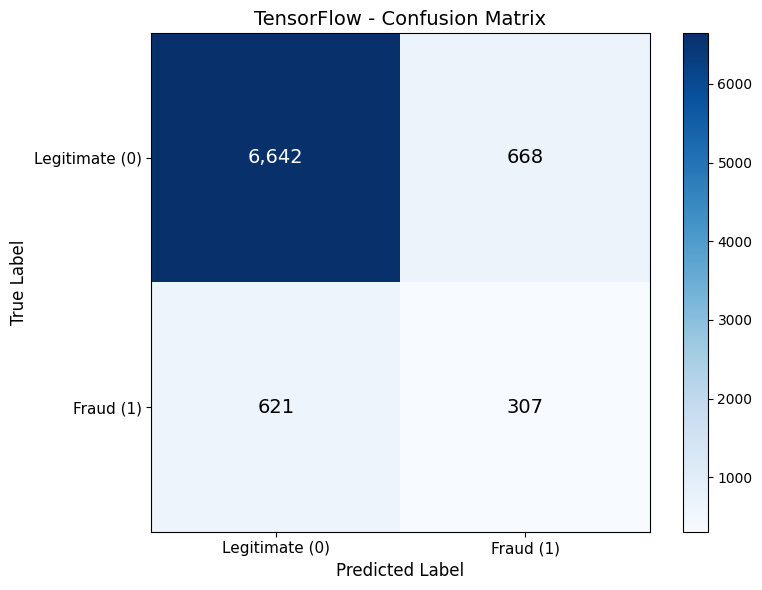

  [1/4] Saved: results/dt_confusion_matrix.png


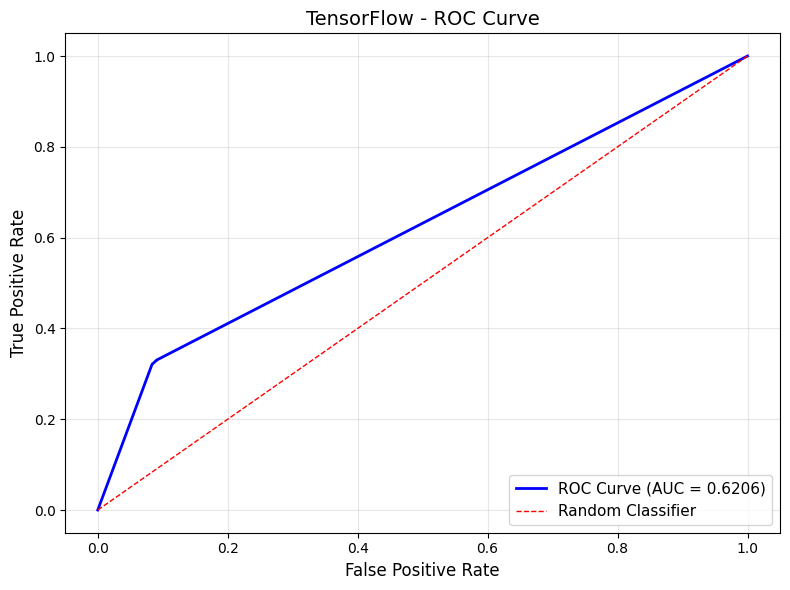

  [2/4] Saved: results/dt_roc_curve.png


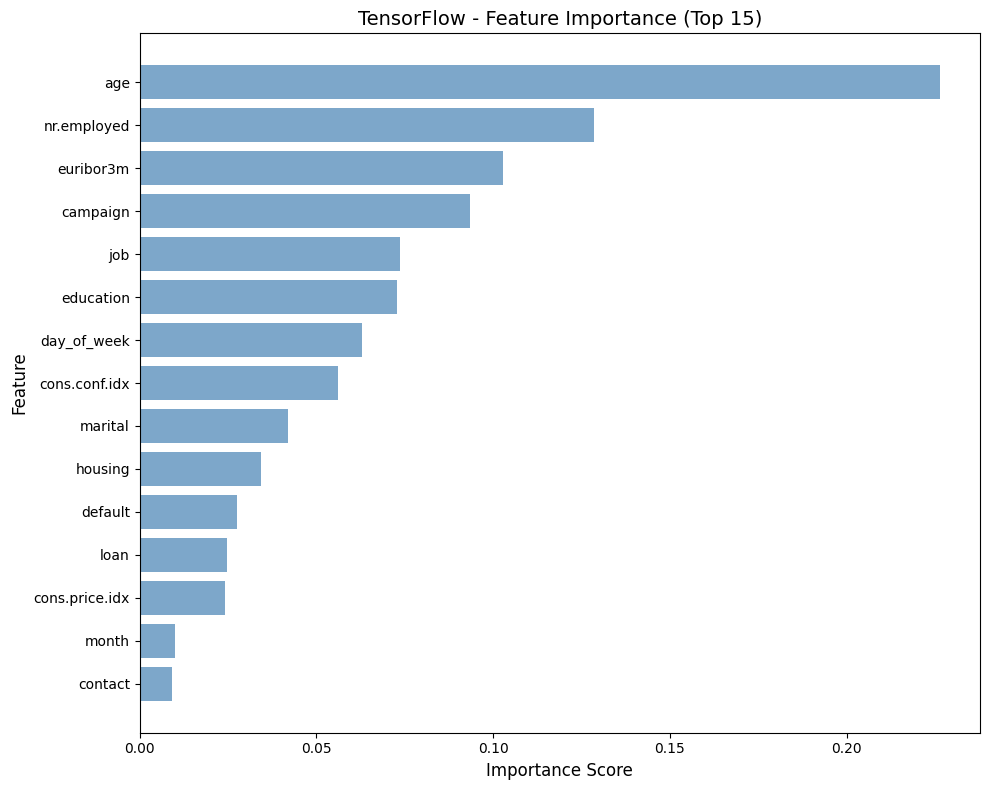

  [3/4] Saved: results/dt_feature_importance.png


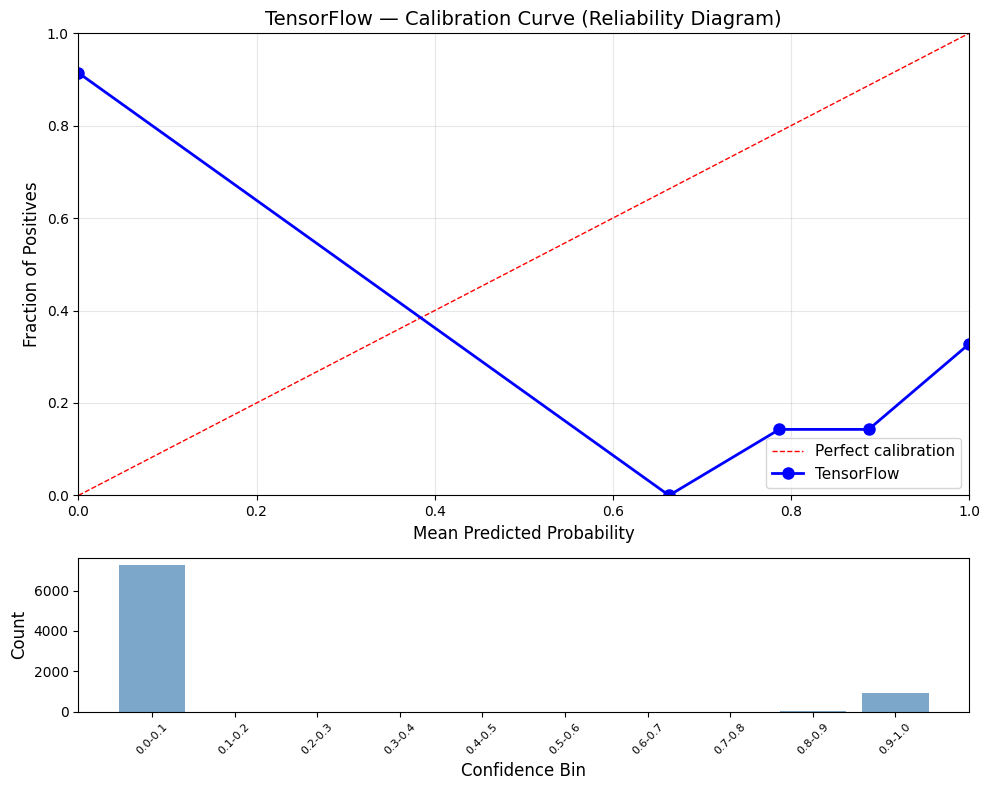

  [4/4] Saved: results/dt_calibration_curve.png


In [8]:
# Step 7: Decision Tree visualizations
"""
4 plots: confusion matrix, ROC curve, feature importance, calibration
All use framework=FRAMEWORK for consistent styling
"""

print("=" * 60)
print("DECISION TREE VISUALIZATIONS")
print("=" * 60)

# 1. Confusion matrix
plot_confusion_matrix(y_test, dt_test_preds.numpy(),
                      framework=FRAMEWORK,
                      save_path=f'{RESULTS_DIR}/dt_confusion_matrix.png')
print(f"  [1/4] Saved: {RESULTS_DIR}/dt_confusion_matrix.png")

# 2. ROC curve — needs 1D P(class=1)
plot_roc_curve(y_test, dt_test_probs[:, 1].numpy(),
               framework=FRAMEWORK,
               save_path=f'{RESULTS_DIR}/dt_roc_curve.png')
print(f"  [2/4] Saved: {RESULTS_DIR}/dt_roc_curve.png")

# 3. Feature importance — from tree_utils.compute_feature_importance
dt_importance = compute_feature_importance(tree, n_features)
plot_feature_importance(dt_importance, feature_names,
                        framework=FRAMEWORK,
                        save_path=f'{RESULTS_DIR}/dt_feature_importance.png',
                        mode='importance')
print(f"  [3/4] Saved: {RESULTS_DIR}/dt_feature_importance.png")

# 4. Calibration curve
plot_calibration_curve(y_test, dt_test_probs[:, 1].numpy(),
                       framework=FRAMEWORK,
                       save_path=f'{RESULTS_DIR}/dt_calibration_curve.png')
print(f"  [4/4] Saved: {RESULTS_DIR}/dt_calibration_curve.png")

In [9]:
# PART 2: RANDOM FOREST

"""
Ensemble of 100 trees with bootstrap sampling and random feature subsets.
Same TF-accelerated split search, but each tree sees a different
bootstrap sample and only sqrt(19) ≈ 4 random features per split.
"""

def bootstrap_sample_tf(X_t, y_t, sample_weight_t, seed):
    """
    Create a bootstrap sample with OOB tracking.

    Args:
        X_t: tf.Tensor (n_samples, n_features) float32
        y_t: tf.Tensor (n_samples,) int64
        sample_weight_t: tf.Tensor (n_samples,) float32
        seed: int — random seed for reproducibility

    Returns:
        X_boot, y_boot, w_boot: bootstrap tensors
        oob_mask: numpy bool array — True for out-of-bag samples
    """
    n = X_t.shape[0]
    tf.random.set_seed(seed)
    indices = tf.random.uniform((n,), 0, n, dtype=tf.int32)

    X_boot = tf.gather(X_t, indices)
    y_boot = tf.gather(y_t, tf.cast(indices, tf.int64))
    w_boot = tf.gather(sample_weight_t, indices)

    # OOB mask: samples NOT selected (use numpy for set ops)
    selected = set(indices.numpy().tolist())
    oob_mask = np.array([i not in selected for i in range(n)])

    return X_boot, y_boot, w_boot, oob_mask

def build_rf_tree_tf(X_t, y_t, sample_weight_t, n_classes, max_features, rng):
    """
    Build a single RF tree with random feature subsets at each split.

    Wraps find_best_split_tf with feature_indices parameter to restrict
    which features are considered at each node.

    Args:
        X_t: tf.Tensor — bootstrap sample features
        y_t: tf.Tensor — bootstrap sample labels
        sample_weight_t: tf.Tensor — bootstrap sample weights
        n_classes: int
        max_features: int — number of features to consider per split
        rng: np.random.RandomState — for reproducible feature selection

    Returns:
        dict: tree node (same format as build_tree_tf)
    """
    def _build(X_t, y_t, sample_weight_t, depth=0):
        n_samples = X_t.shape[0]
        n_feat = X_t.shape[1]

        # Class distribution
        one_hot = tf.one_hot(tf.cast(y_t, tf.int32), depth=n_classes, dtype=tf.float32)
        weighted_counts = tf.reduce_sum(one_hot * sample_weight_t[:, tf.newaxis], axis=0)
        value = weighted_counts.numpy().tolist()
        impurity = float(gini_impurity_tf(y_t, sample_weight_t))

        # Stopping: pure node
        unique_classes = tf.unique(y_t)[0]
        if tf.shape(unique_classes)[0] == 1:
            return {'value': value, 'n_samples': int(n_samples), 'impurity': 0.0}

        if n_samples < 2:
            return {'value': value, 'n_samples': int(n_samples), 'impurity': impurity}

        # Random feature subset
        feature_indices = rng.choice(n_feat, size=max_features, replace=False).tolist()

        best = find_best_split_tf(X_t, y_t, sample_weight_t, feature_indices=feature_indices)

        if best is None or best['gain'] <= 0:
            return {'value': value, 'n_samples': int(n_samples), 'impurity': impurity}

        feat = best['feature']
        thresh = best['threshold']

        left_mask = X_t[:, feat] <= thresh
        right_mask = ~left_mask

        X_left = tf.boolean_mask(X_t, left_mask)
        y_left = tf.boolean_mask(y_t, left_mask)
        w_left = tf.boolean_mask(sample_weight_t, left_mask)

        X_right = tf.boolean_mask(X_t, right_mask)
        y_right = tf.boolean_mask(y_t, right_mask)
        w_right = tf.boolean_mask(sample_weight_t, right_mask)

        if X_left.shape[0] == 0 or X_right.shape[0] == 0:
            return {'value': value, 'n_samples': int(n_samples), 'impurity': impurity}

        left_child = _build(X_left, y_left, w_left, depth + 1)
        right_child = _build(X_right, y_right, w_right, depth + 1)

        return {
            'feature': int(feat),
            'threshold': float(thresh),
            'left': left_child,
            'right': right_child,
            'n_samples': int(n_samples),
            'impurity': impurity,
            'value': value
        }

    return _build(X_t, y_t, sample_weight_t)

def build_forest_tf(X_t, y_t, sample_weight_t, n_classes, n_estimators, max_features):
    """
    Build a Random Forest — sequential tree construction.

    Args:
        X_t, y_t, sample_weight_t: training tensors
        n_classes: int
        n_estimators: int — number of trees
        max_features: int — features per split

    Returns:
        forest: list of tree dicts
        oob_masks: list of numpy bool arrays
    """
    forest = []
    oob_masks = []

    # max_features from string to int
    n_feat = X_t.shape[1]
    if isinstance(max_features, str) and max_features == 'sqrt':
        max_f = int(np.sqrt(n_feat))
    else:
        max_f = int(max_features)

    print(f"  Building {n_estimators} trees (max_features={max_f})...")

    for i in range(n_estimators):
        seed = RANDOM_STATE + i
        rng = np.random.RandomState(seed)

        X_boot, y_boot, w_boot, oob_mask = bootstrap_sample_tf(
            X_t, y_t, sample_weight_t, seed)

        tree_i = build_rf_tree_tf(X_boot, y_boot, w_boot, n_classes, max_f, rng)
        forest.append(tree_i)
        oob_masks.append(oob_mask)

        if (i + 1) % 10 == 0:
            print(f"    Trees: {i+1}/{n_estimators}")

    return forest, oob_masks

def predict_forest_tf(forest, X_t):
    """
    Average predictions across all trees in the forest.

    Each tree: flatten → TF tensors → predict_tree_tf → probabilities.
    Final: average probabilities, argmax for class labels.

    Args:
        forest: list of tree dicts
        X_t: tf.Tensor (n_samples, n_features) float32

    Returns:
        predictions: tf.Tensor (n_samples,) int64
        probabilities: tf.Tensor (n_samples, n_classes) float32
    """
    all_probs = []

    for tree_i in forest:
        flat_i = flatten_tree(tree_i)
        flat_tf_i = flat_tree_to_tf(flat_i)
        _, probs_i = predict_tree_tf(flat_tf_i, X_t)
        all_probs.append(probs_i)

    # Stack and average: (n_trees, n_samples, n_classes) → (n_samples, n_classes)
    avg_probs = tf.reduce_mean(tf.stack(all_probs), axis=0)

    # Clamp for log-loss safety
    avg_probs = tf.clip_by_value(avg_probs, 1e-7, 1.0 - 1e-7)

    predictions = tf.argmax(avg_probs, axis=1)
    return predictions, avg_probs


print("=" * 60)
print("PART 2: RANDOM FOREST")
print("=" * 60)
print("  Functions defined: bootstrap_sample_tf, build_rf_tree_tf,")
print("                     build_forest_tf, predict_forest_tf")
print(f"  Config: {N_ESTIMATORS} trees, max_features='{MAX_FEATURES}'")

PART 2: RANDOM FOREST
  Functions defined: bootstrap_sample_tf, build_rf_tree_tf,
                     build_forest_tf, predict_forest_tf
  Config: 100 trees, max_features='sqrt'


In [10]:
# Step 9: Random Forest — training + evaluation
# ============================================================

print("=" * 60)
print("RANDOM FOREST TRAINING (100 trees)")
print("=" * 60)

with track_performance() as rf_perf:
    forest, oob_masks = build_forest_tf(X_train_t, y_train_t, sample_weight_t,
                                         n_classes, N_ESTIMATORS, MAX_FEATURES)

print(f"\n  [1/3] Forest built in {rf_perf['time']:.1f}s")
print(f"  Peak memory: {rf_perf['memory']:.2f} MB")

# Tree stats
depths = [get_tree_depth(t) for t in forest]
leaves = [get_n_leaves(t) for t in forest]
print(f"  Avg depth: {np.mean(depths):.1f} (range: {min(depths)}-{max(depths)})")
print(f"  Avg leaves: {np.mean(leaves):.0f} (range: {min(leaves)}-{max(leaves)})")

# Train predictions
rf_train_preds, rf_train_probs = predict_forest_tf(forest, X_train_t)
rf_train_metrics = evaluate_classifier(y_train, rf_train_preds.numpy(),
                                        rf_train_probs[:, 1].numpy())

# Test predictions
rf_test_preds, rf_test_probs = predict_forest_tf(forest, X_test_t)
rf_test_metrics = evaluate_classifier(y_test, rf_test_preds.numpy(),
                                       rf_test_probs[:, 1].numpy())

print(f"\n  [2/3] Predictions complete")
print_metrics(rf_train_metrics, rf_test_metrics, title="Random Forest (100 trees)")

print(f"\n  [3/3] Random Forest complete")

RANDOM FOREST TRAINING (100 trees)
  Building 100 trees (max_features=4)...
    Trees: 10/100
    Trees: 20/100
    Trees: 30/100
    Trees: 40/100
    Trees: 50/100
    Trees: 60/100
    Trees: 70/100
    Trees: 80/100
    Trees: 90/100
    Trees: 100/100

  [1/3] Forest built in 11950.4s
  Peak memory: 215.58 MB
  Avg depth: 30.1 (range: 26-36)
  Avg leaves: 2944 (range: 2434-3269)

  [2/3] Predictions complete

METRICS — Random Forest (100 trees)
Metric                           Train         Test
-------------------------------------------------
accuracy                        0.9768       0.8908
precision                       0.9219       0.5226
recall                          0.8677       0.3491
f1                              0.8940       0.4186
auc                             0.9961       0.7814
log_loss                        0.1765       0.3171
brier_score                     0.0364       0.0900
ece                             0.7790       0.7169

  [3/3] Random Forest compl

RANDOM FOREST VISUALIZATIONS


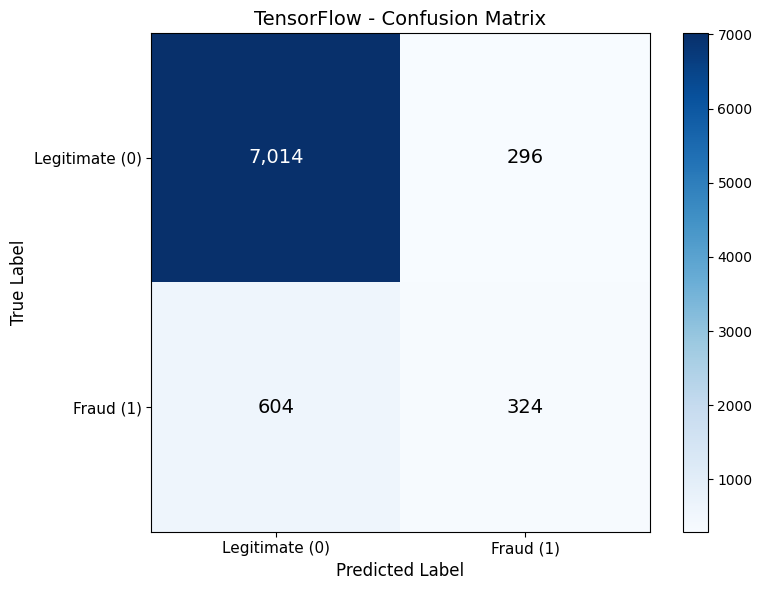

  [1/5] Saved: results/rf_confusion_matrix.png


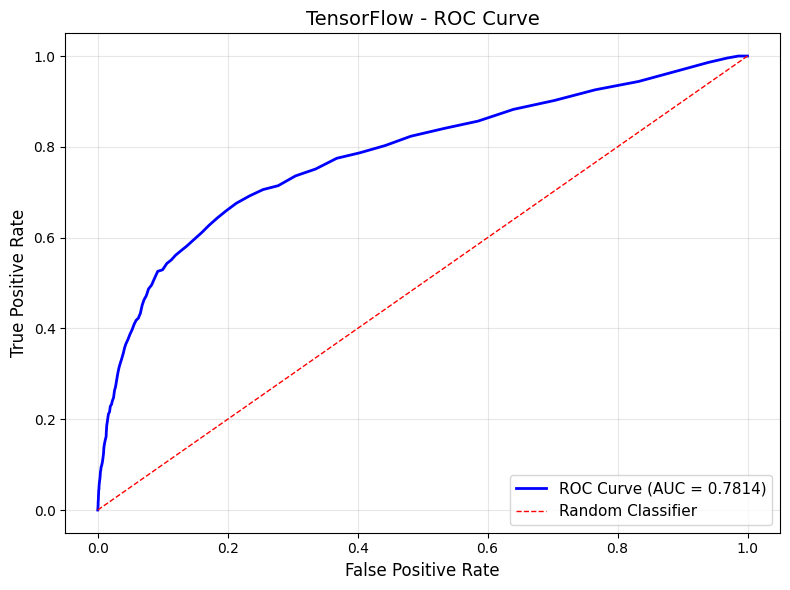

  [2/5] Saved: results/rf_roc_curve.png


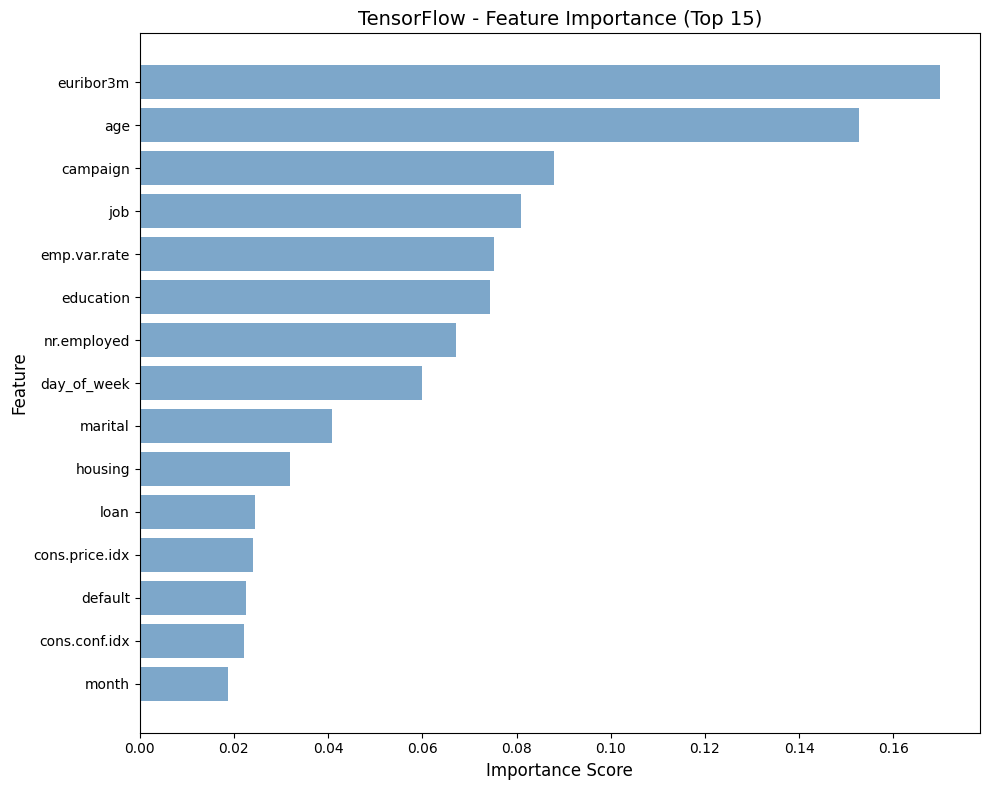

  [3/5] Saved: results/rf_feature_importance.png


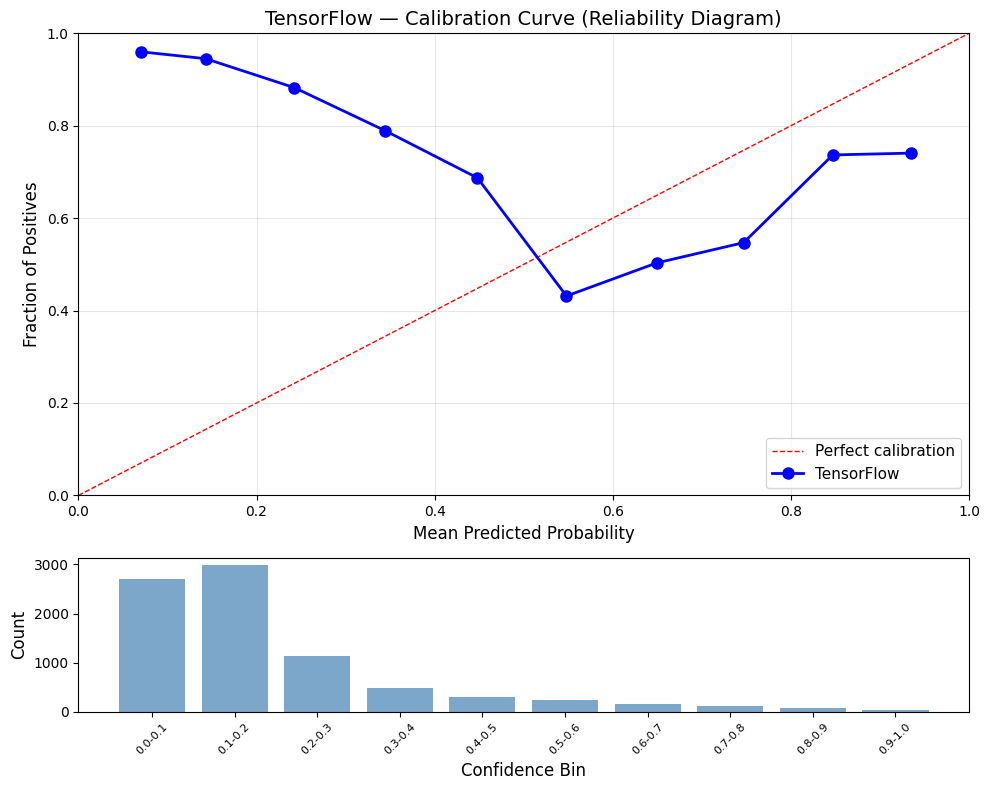

  [4/5] Saved: results/rf_calibration_curve.png
  Computing convergence curve...
    Convergence: 20/100
    Convergence: 40/100
    Convergence: 60/100
    Convergence: 80/100
    Convergence: 100/100


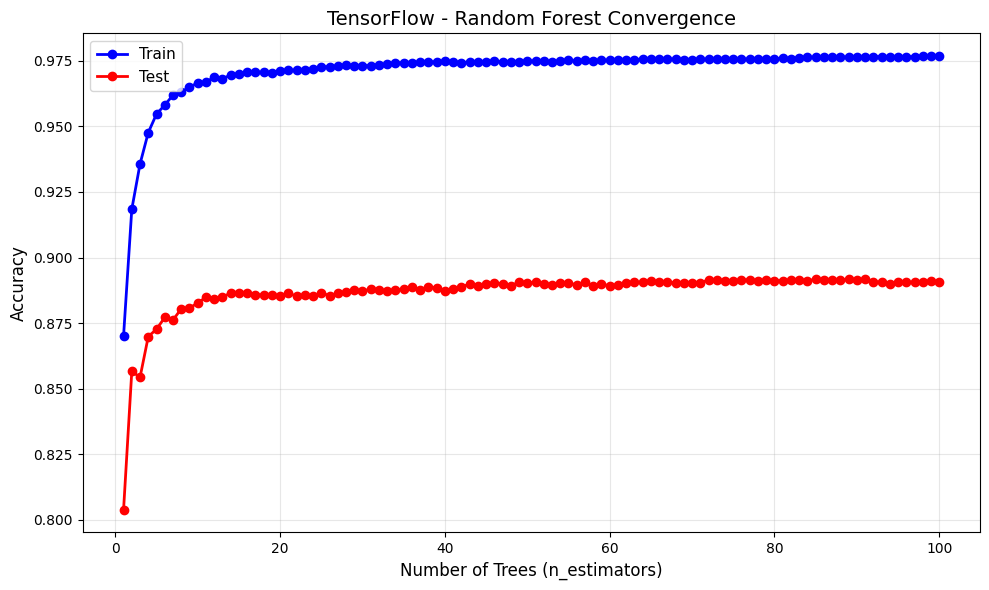

  [5/5] Saved: results/rf_convergence.png


In [11]:
# Step 10: Random Forest visualizations

# 5 plots: confusion matrix, ROC, feature importance, calibration, convergence

print("=" * 60)
print("RANDOM FOREST VISUALIZATIONS")
print("=" * 60)

# 1. Confusion matrix
plot_confusion_matrix(y_test, rf_test_preds.numpy(),
                      framework=FRAMEWORK,
                      save_path=f'{RESULTS_DIR}/rf_confusion_matrix.png')
print(f"  [1/5] Saved: {RESULTS_DIR}/rf_confusion_matrix.png")

# 2. ROC curve
plot_roc_curve(y_test, rf_test_probs[:, 1].numpy(),
               framework=FRAMEWORK,
               save_path=f'{RESULTS_DIR}/rf_roc_curve.png')
print(f"  [2/5] Saved: {RESULTS_DIR}/rf_roc_curve.png")

# 3. Feature importance — averaged across all 100 trees
all_importances = np.zeros(n_features)
for t in forest:
    all_importances += compute_feature_importance(t, n_features)
all_importances /= len(forest)

plot_feature_importance(all_importances, feature_names,
                        framework=FRAMEWORK,
                        save_path=f'{RESULTS_DIR}/rf_feature_importance.png',
                        mode='importance')
print(f"  [3/5] Saved: {RESULTS_DIR}/rf_feature_importance.png")

# 4. Calibration curve
plot_calibration_curve(y_test, rf_test_probs[:, 1].numpy(),
                       framework=FRAMEWORK,
                       save_path=f'{RESULTS_DIR}/rf_calibration_curve.png')
print(f"  [4/5] Saved: {RESULTS_DIR}/rf_calibration_curve.png")

# 5. Forest convergence — accuracy vs number of trees
print(f"  Computing convergence curve...")
conv_train_scores = []
conv_test_scores = []
n_values = list(range(1, N_ESTIMATORS + 1, 1))

for n in n_values:
    subset_preds_train, _ = predict_forest_tf(forest[:n], X_train_t)
    subset_preds_test, _ = predict_forest_tf(forest[:n], X_test_t)
    conv_train_scores.append(accuracy(y_train, subset_preds_train.numpy()))
    conv_test_scores.append(accuracy(y_test, subset_preds_test.numpy()))
    if n % 20 == 0:
        print(f"    Convergence: {n}/{N_ESTIMATORS}")

plot_forest_convergence(n_values, conv_train_scores, conv_test_scores,
                        framework=FRAMEWORK,
                        save_path=f'{RESULTS_DIR}/rf_convergence.png')
print(f"  [5/5] Saved: {RESULTS_DIR}/rf_convergence.png")

In [12]:
# Step 11: Showcase — TF CPU vs NumPy split search
"""
Same sorted-scan algorithm, two implementations:
  TF:    tf.sort + tf.cumsum → ALL thresholds evaluated simultaneously (vectorized)
  NumPy: np.argsort + Python for-loop → one threshold at a time (sequential)

Both are CPU-bound. The question: does TF's vectorized cumsum
overcome its eager dispatch overhead vs NumPy's direct C calls?
"""

def find_best_split_numpy(X, y, sample_weight):
    """
    NumPy sorted-scan split search (from No-Framework pipeline).

    Same algorithm as find_best_split_tf, but uses:
    - np.argsort (single sort call)
    - Python for-loop scanning thresholds one at a time
    - Running left_w / right_w arrays updated incrementally

    Args:
        X: numpy array (n_samples, n_features) float64
        y: numpy array (n_samples,) int
        sample_weight: numpy array (n_samples,) float64

    Returns:
        dict with 'feature', 'threshold', 'gain', or None
    """
    n_samples, n_features = X.shape
    n_classes = 2

    # Parent Gini
    total_w = sample_weight.sum()
    parent_gini = 0.0
    for c in range(n_classes):
        p = sample_weight[y == c].sum() / total_w
        parent_gini += p ** 2
    parent_gini = 1.0 - parent_gini

    best_gain = 0.0
    best_split = None

    for feat in range(n_features):
        sorted_idx = np.argsort(X[:, feat])
        sorted_y = y[sorted_idx]
        sorted_w = sample_weight[sorted_idx]
        sorted_vals = X[sorted_idx, feat]

        # All samples start in right child
        left_w = np.zeros(n_classes)
        right_w = np.zeros(n_classes)
        for c in range(n_classes):
            right_w[c] = sorted_w[sorted_y == c].sum()

        # Scan left to right
        for i in range(n_samples - 1):
            c = int(sorted_y[i])
            left_w[c] += sorted_w[i]
            right_w[c] -= sorted_w[i]

            # Skip identical consecutive values
            if sorted_vals[i] == sorted_vals[i + 1]:
                continue

            left_total = left_w.sum()
            right_total = right_w.sum()

            # Gini for left and right
            left_p = left_w / left_total
            right_p = right_w / right_total
            left_gini = 1.0 - np.sum(left_p ** 2)
            right_gini = 1.0 - np.sum(right_p ** 2)

            child_imp = (left_total / total_w * left_gini +
                         right_total / total_w * right_gini)
            gain = parent_gini - child_imp

            if gain > best_gain:
                best_gain = gain
                best_split = {
                    'feature': feat,
                    'threshold': (sorted_vals[i] + sorted_vals[i + 1]) / 2,
                    'gain': gain
                }

    return best_split

In [13]:
print("=" * 60)
print("SHOWCASE: TF CPU vs NumPy Split Search")
print("=" * 60)

N_RUNS = 50

# Prepare data — same data, different formats
X_np = X_train.astype(np.float64)
y_np = y_train.astype(np.int64)
w_np = sample_weight_t.numpy().astype(np.float64)

# Verify both produce the same result
tf_result = find_best_split_tf(X_train_t, y_train_t, sample_weight_t)
np_result = find_best_split_numpy(X_np, y_np, w_np)

print(f"\n  Verification (same split found):")
print(f"    TF:    {feature_names[tf_result['feature']]} <= {tf_result['threshold']:.4f}, "
      f"gain={tf_result['gain']:.6f}")
print(f"    NumPy: {feature_names[np_result['feature']]} <= {np_result['threshold']:.4f}, "
      f"gain={np_result['gain']:.6f}")

# Warmup (3 runs each — TF eager has first-call overhead)
print(f"\n  Warming up (3 runs each)...")
for _ in range(3):
    find_best_split_tf(X_train_t, y_train_t, sample_weight_t)
    find_best_split_numpy(X_np, y_np, w_np)

# Benchmark TF
print(f"  Benchmarking TF ({N_RUNS} runs)...")
tf_times = []
for _ in range(N_RUNS):
    t0 = time.perf_counter()
    find_best_split_tf(X_train_t, y_train_t, sample_weight_t)
    tf_times.append(time.perf_counter() - t0)

# Benchmark NumPy
print(f"  Benchmarking NumPy ({N_RUNS} runs)...")
np_times = []
for _ in range(N_RUNS):
    t0 = time.perf_counter()
    find_best_split_numpy(X_np, y_np, w_np)
    np_times.append(time.perf_counter() - t0)

tf_mean = np.mean(tf_times) * 1000  # ms
np_mean = np.mean(np_times) * 1000  # ms
tf_std = np.std(tf_times) * 1000
np_std = np.std(np_times) * 1000

print(f"\n{'=' * 60}")
print(f"RESULTS ({N_RUNS} runs, {X_train.shape[0]:,} samples × {n_features} features)")
print(f"{'=' * 60}")
print(f"  TF CPU (vectorized):    {tf_mean:.2f} ± {tf_std:.2f} ms/split")
print(f"  NumPy (for-loop):       {np_mean:.2f} ± {np_std:.2f} ms/split")
print(f"{'=' * 60}")

if tf_mean < np_mean:
    speedup = np_mean / tf_mean
    print(f"  TF is {speedup:.2f}x FASTER than NumPy")
    print(f"\n  Why: TF's vectorized tf.cumsum evaluates ALL {X_train.shape[0]-1:,}")
    print(f"  thresholds per feature simultaneously, while NumPy's Python")
    print(f"  for-loop processes them one at a time. At {X_train.shape[0]:,} samples,")
    print(f"  the vectorization advantage outweighs TF's eager dispatch overhead.")
else:
    speedup = tf_mean / np_mean
    print(f"  NumPy is {speedup:.2f}x FASTER than TF")
    print(f"\n  Why: TF's eager dispatch overhead (Python→C++ bridge per op)")
    print(f"  and memory allocation for intermediate tensors outweigh the")
    print(f"  vectorization benefit. NumPy's compiled C routines with")
    print(f"  incremental O(1) updates avoid this overhead entirely.")


SHOWCASE: TF CPU vs NumPy Split Search

  Verification (same split found):
    TF:    nr.employed <= 5087.6501, gain=0.098501
    NumPy: nr.employed <= 5087.6500, gain=0.098497

  Warming up (3 runs each)...
  Benchmarking TF (50 runs)...
  Benchmarking NumPy (50 runs)...

RESULTS (50 runs, 32,950 samples × 19 features)
  TF CPU (vectorized):    313.07 ± 4.86 ms/split
  NumPy (for-loop):       296.12 ± 5.35 ms/split
  NumPy is 1.06x FASTER than TF

  Why: TF's eager dispatch overhead (Python→C++ bridge per op)
  and memory allocation for intermediate tensors outweigh the
  vectorization benefit. NumPy's compiled C routines with
  incremental O(1) updates avoid this overhead entirely.


In [15]:
# Step 12: Save results + cross-framework comparison
"""
pickle for model size (not get_model_size — expects nn.Module/keras)
track_inference with n_runs=3 (forest prediction is slow)
4/4 frameworks complete!
"""

print("=" * 60)
print("SAVE RESULTS")
print("=" * 60)

# Model size via pickle (forest is a list of Python dicts)
model_size = len(pickle.dumps(forest))
print(f"  [1/4] Model size: {model_size / (1024*1024):.2f} MB")

# Inference timing — wrapper converts numpy→TF→predict→numpy
def predict_fn(X_np):
    X_tf = tf.constant(X_np, dtype=tf.float32)
    preds, _ = predict_forest_tf(forest, X_tf)
    return preds.numpy()

inference_stats = track_inference(predict_fn, X_test, n_runs=3)
print(f"  [2/4] Inference: {inference_stats['per_sample_us']:.2f} µs/sample")

# Build and save results
results = build_results_dict(
    FRAMEWORK, 'RandomForest', rf_test_metrics, rf_perf,
    inference_stats, model_size,
    n_estimators=N_ESTIMATORS,
    dt_test_accuracy=dt_test_metrics['accuracy'],
    dt_test_f1=dt_test_metrics['f1']
)
save_results(results, save_dir=RESULTS_DIR)
print(f"  [3/4] Results saved to {RESULTS_DIR}/")

# Add to cross-framework comparison
add_result('decision_tree', results)
print(f"\n  [4/4] Cross-framework comparison (4/4):")
print_comparison('decision_tree')


SAVE RESULTS
  [1/4] Model size: 29.50 MB
  [2/4] Inference: 725.14 µs/sample
    Results saved to: results\metrics.json
  [3/4] Results saved to results/
    Added 'TensorFlow' to C:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\data\results\decision_tree.json
    Frameworks recorded: 4/4

  [4/4] Cross-framework comparison (4/4):

CROSS-FRAMEWORK COMPARISON: DECISION_TREE
Metric                          Scikit-Learn  No-Framework       PyTorch    TensorFlow
--------------------------------------------------------------------------------------
model                           RandomForest  RandomForest  RandomForest  RandomForest
training_time                        21.19 s      29.2 min      24.6 min     199.2 min
inference_time_per_sample_us         3.39 µs     169.46 µs     279.79 µs     725.14 µs
model_size_bytes                    11.50 MB      55.23 MB      29.47 MB      29.50 MB
peak_memory_mb                      62.17 MB     251.62 MB     225.15 MB     215.5